
# Feature Extraction from BVP (PPG) Signal


In [7]:

# Cell 1: Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt
import heartpy as hp


c:\Users\Sulo\miniconda3\envs\pulse_ppg\lib\site-packages\heartpy\datautils.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename


In [8]:

# Cell 2: Load BVP.csv 
# First row = sampling rate, remaining rows = signal

bvp_path = "data/S1/BVP.csv"

df = pd.read_csv(bvp_path, header=None)

fs = int(df.iloc[0, 0])      # sampling rate
bvp = df.iloc[1:, 0].values # signal values

print("Sampling rate:", fs)
print("Signal length:", len(bvp))


Sampling rate: 1530261892
Signal length: 597906


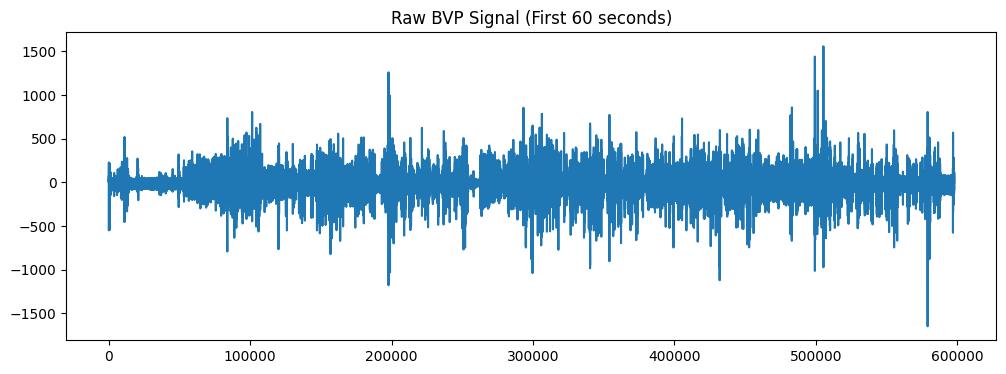

In [9]:

# Cell 3: Plot raw BVP signal (visual check)
plt.figure(figsize=(12,4))
plt.plot(bvp[:fs*60])
plt.title("Raw BVP Signal (First 60 seconds)")
plt.show()


In [10]:

# Cell 4: Band-pass filter (0.7–4 Hz)

def bandpass_filter(signal, fs, low=0.7, high=4.0, order=3):
    nyq = 0.5 * fs
    b, a = butter(order, [low/nyq, high/nyq], btype='band')
    return filtfilt(b, a, signal)

filtered_bvp = bandpass_filter(bvp, fs)

# Normalize
filtered_bvp = (filtered_bvp - np.mean(filtered_bvp)) / np.std(filtered_bvp)


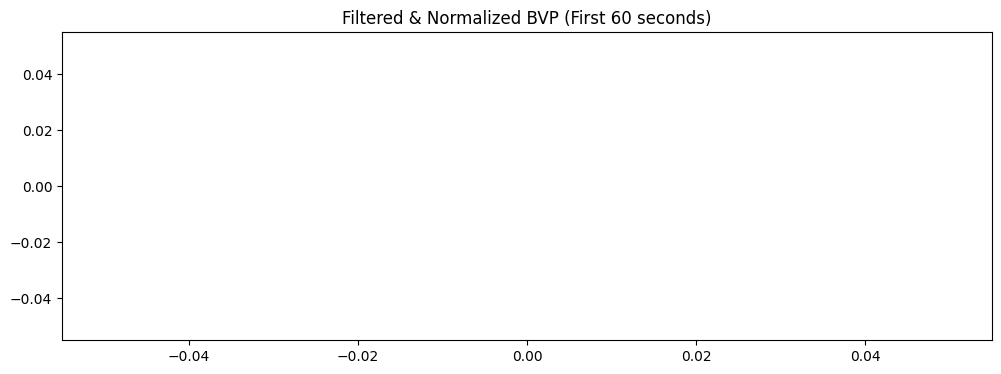

In [11]:

# Cell 5: Plot filtered signal
plt.figure(figsize=(12,4))
plt.plot(filtered_bvp[:fs*60])
plt.title("Filtered & Normalized BVP (First 60 seconds)")
plt.show()


In [12]:

# Cell 6: Select safe 30-second segment (skip first 60s)
start = fs * 60
segment = filtered_bvp[start:start + fs*30]

print("Segment length:", len(segment))


Segment length: 0


In [15]:
# Feature Extraction (VERY IMPORTANT STEP)

if segment.size == 0:
    print("Error: 'segment' is empty. Please check your signal extraction step.")
    features = None
else:
    features = {
        "mean": np.mean(segment),
        "std": np.std(segment),
        "variance": np.var(segment),
        "max": np.max(segment),
        "min": np.min(segment),
        "range": np.max(segment) - np.min(segment),
        "skew": pd.Series(segment).skew(),
        "kurtosis": pd.Series(segment).kurtosis(),
        "energy": np.sum(segment**2)
    }
    print(features)

Error: 'segment' is empty. Please check your signal extraction step.


In [ ]:

# Cell 7: Heart rate extraction using HeartPy
#wd, m = hp.process(
#    segment,
#    sample_rate=fs,
#    bpmmin=45,
#    bpmmax=160,
#    windowsize=0.75
#)

#print("Estimated Heart Rate (BPM):", round(m['bpm'], 2))


NameError: name 'hp' is not defined

NameError: name 'wd' is not defined

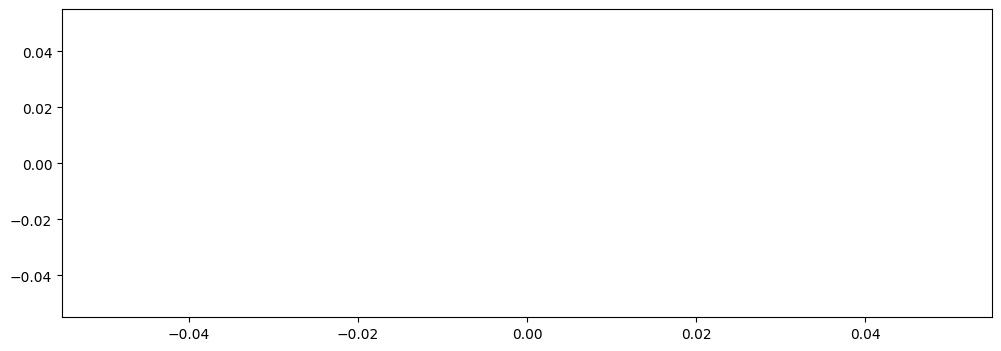

In [ ]:

# Cell 8: Visualize detected peaks
plt.figure(figsize=(12,4))
plt.plot(segment, label="Filtered BVP")
plt.scatter(wd['peaklist'], segment[wd['peaklist']], color='red', s=30, label="Detected Peaks")
plt.legend()
plt.title("Detected Heartbeats")
plt.show()


In [6]:
# Save features to CSV

if 'features' in globals():
	df_features = pd.DataFrame([features])
	df_features.to_csv("features.csv", mode='a', header=not pd.io.common.file_exists("features.csv"), index=False)
	print("Features saved!")
else:
	print("Error: 'features' is not defined. Please run the feature extraction cell first.")

Error: 'features' is not defined. Please run the feature extraction cell first.



## Notes for Final Year Project

- Some segments may fail due to motion artifacts
- This is normal in real-world PPG data
- Invalid segments can be rejected automatically
- Features extracted here can be saved to CSV for ML training
